<a href="https://colab.research.google.com/github/Ash3rC/Works/blob/main/trend_analysis_of_the_environmental_parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import warnings
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.ticker as mticker
import sklearn
sns.set_theme(style='whitegrid', font_scale=0.8)
warnings.filterwarnings('ignore')

# ML
import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# Classification

from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

#file saves
from google.colab import files
print(gpd.__version__)
print(pd.__version__)
print(np.__version__)
print(shap.__version__)
print(sns.__version__)
print(xgb.__version__)
print(sklearn.__version__)

1.1.3
2.2.2
2.0.2
0.52.0
0.13.2
3.3.0
1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

hsl = pd.read_csv('/content/drive/MyDrive/HSL_Lake_ML_Data.csv')

Mounted at /content/drive


In [ ]:
hsl

,Date,NDCI,NDTI,SDD_mean_m_Value,NO2_column_scaled_x1e6,SO2_column_scaled_x1e6,O3_column_scaled_x1e6,CO_column_scaled_x1e6,Aerosol_Index,TMax (C),TMin (C),Relative_Humidity (%),Rainfall (mm),Mean_Wind_Speed (m/s),Maximum_Wind_Gust (m/s),Dominant_Wind_Direction (),Sunshine_Duration (s),Potential_Evapotranspiration (mm),Cloud_Cover (%),soil_moisture_0_to_7cm (m_/m_)
0,1/1/2020,0.104,-0.124,0.444000,38.17900,453.6986,152440.55,31356.380,-1.174,12.4,-1.5,58,0.0,4.35,12.2,197,33698.97,2.11,0,0.388
1,1/4/2020,0.012,-0.010,0.431308,53.67025,365.8385,155050.97,33051.650,-0.397,4.6,-0.9,76,0.0,4.05,13.9,290,15322.09,0.78,51,0.379
2,1/6/2020,0.137,-0.187,0.422846,72.78300,307.2651,137886.00,31437.295,-1.992,8.0,-3.2,66,0.0,2.18,5.9,40,33401.82,1.26,45,0.368
3,1/9/2020,0.019,-0.010,0.410154,69.49100,219.4050,136911.68,37041.980,-0.473,13.2,5.6,62,17.5,6.82,17.6,179,10423.67,2.12,96,0.363
4,1/11/2020,-0.031,-0.003,0.401692,86.64900,160.8316,149594.37,35998.235,-1.759,15.6,-0.3,90,60.5,5.03,22.3,313,3381.30,0.43,100,0.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,12/23/2025,0.071,-0.210,0.643000,69.44200,-193.8830,118662.04,29750.510,-0.238,19.2,6.3,89,0.1,2.56,7.8,234,29091.87,1.09,52,0.300
864,12/25/2025,0.033,-0.037,0.579286,88.26400,-193.8830,111249.90,29646.730,-0.115,18.4,11.9,96,0.0,2.26,8.5,172,1281.43,0.53,71,0.302
865,12/27/2025,-0.032,0.004,0.515571,38.22700,-193.8830,117878.97,29012.990,-1.481,16.8,6.7,96,0.0,3.31,10.2,136,8423.80,0.56,92,0.300
866,12/28/2025,0.033,-0.009,0.483714,38.22700,-193.8830,117858.76,26430.590,-0.337,23.5,-2.5,80,2.0,6.19,18.5,237,26330.65,1.70,88,0.321


In [ ]:
#parsing and sorting by chronological order for the sake of simplicity
hsl['Date'] = pd.to_datetime(hsl['Date'])
hsl = hsl.sort_values('Date').reset_index(drop=True)

#renaming columns for the sake of clean and consistent code
hsl.columns = [
    'Date', 'NDCI', 'NDTI', 'SDD',
    'NO2', 'SO2', 'O3', 'CO', 'Aerosol_Index',
    'TMax', 'TMin', 'RH', 'Rainfall',
    'Wind_Speed', 'Wind_Gust', 'Wind_Direction',
    'Sunshine_Duration', 'PET', 'Cloud_Cover', 'Soil_Moisture'
]

# Sanity Check ->

In [ ]:
pip install pymannkendall

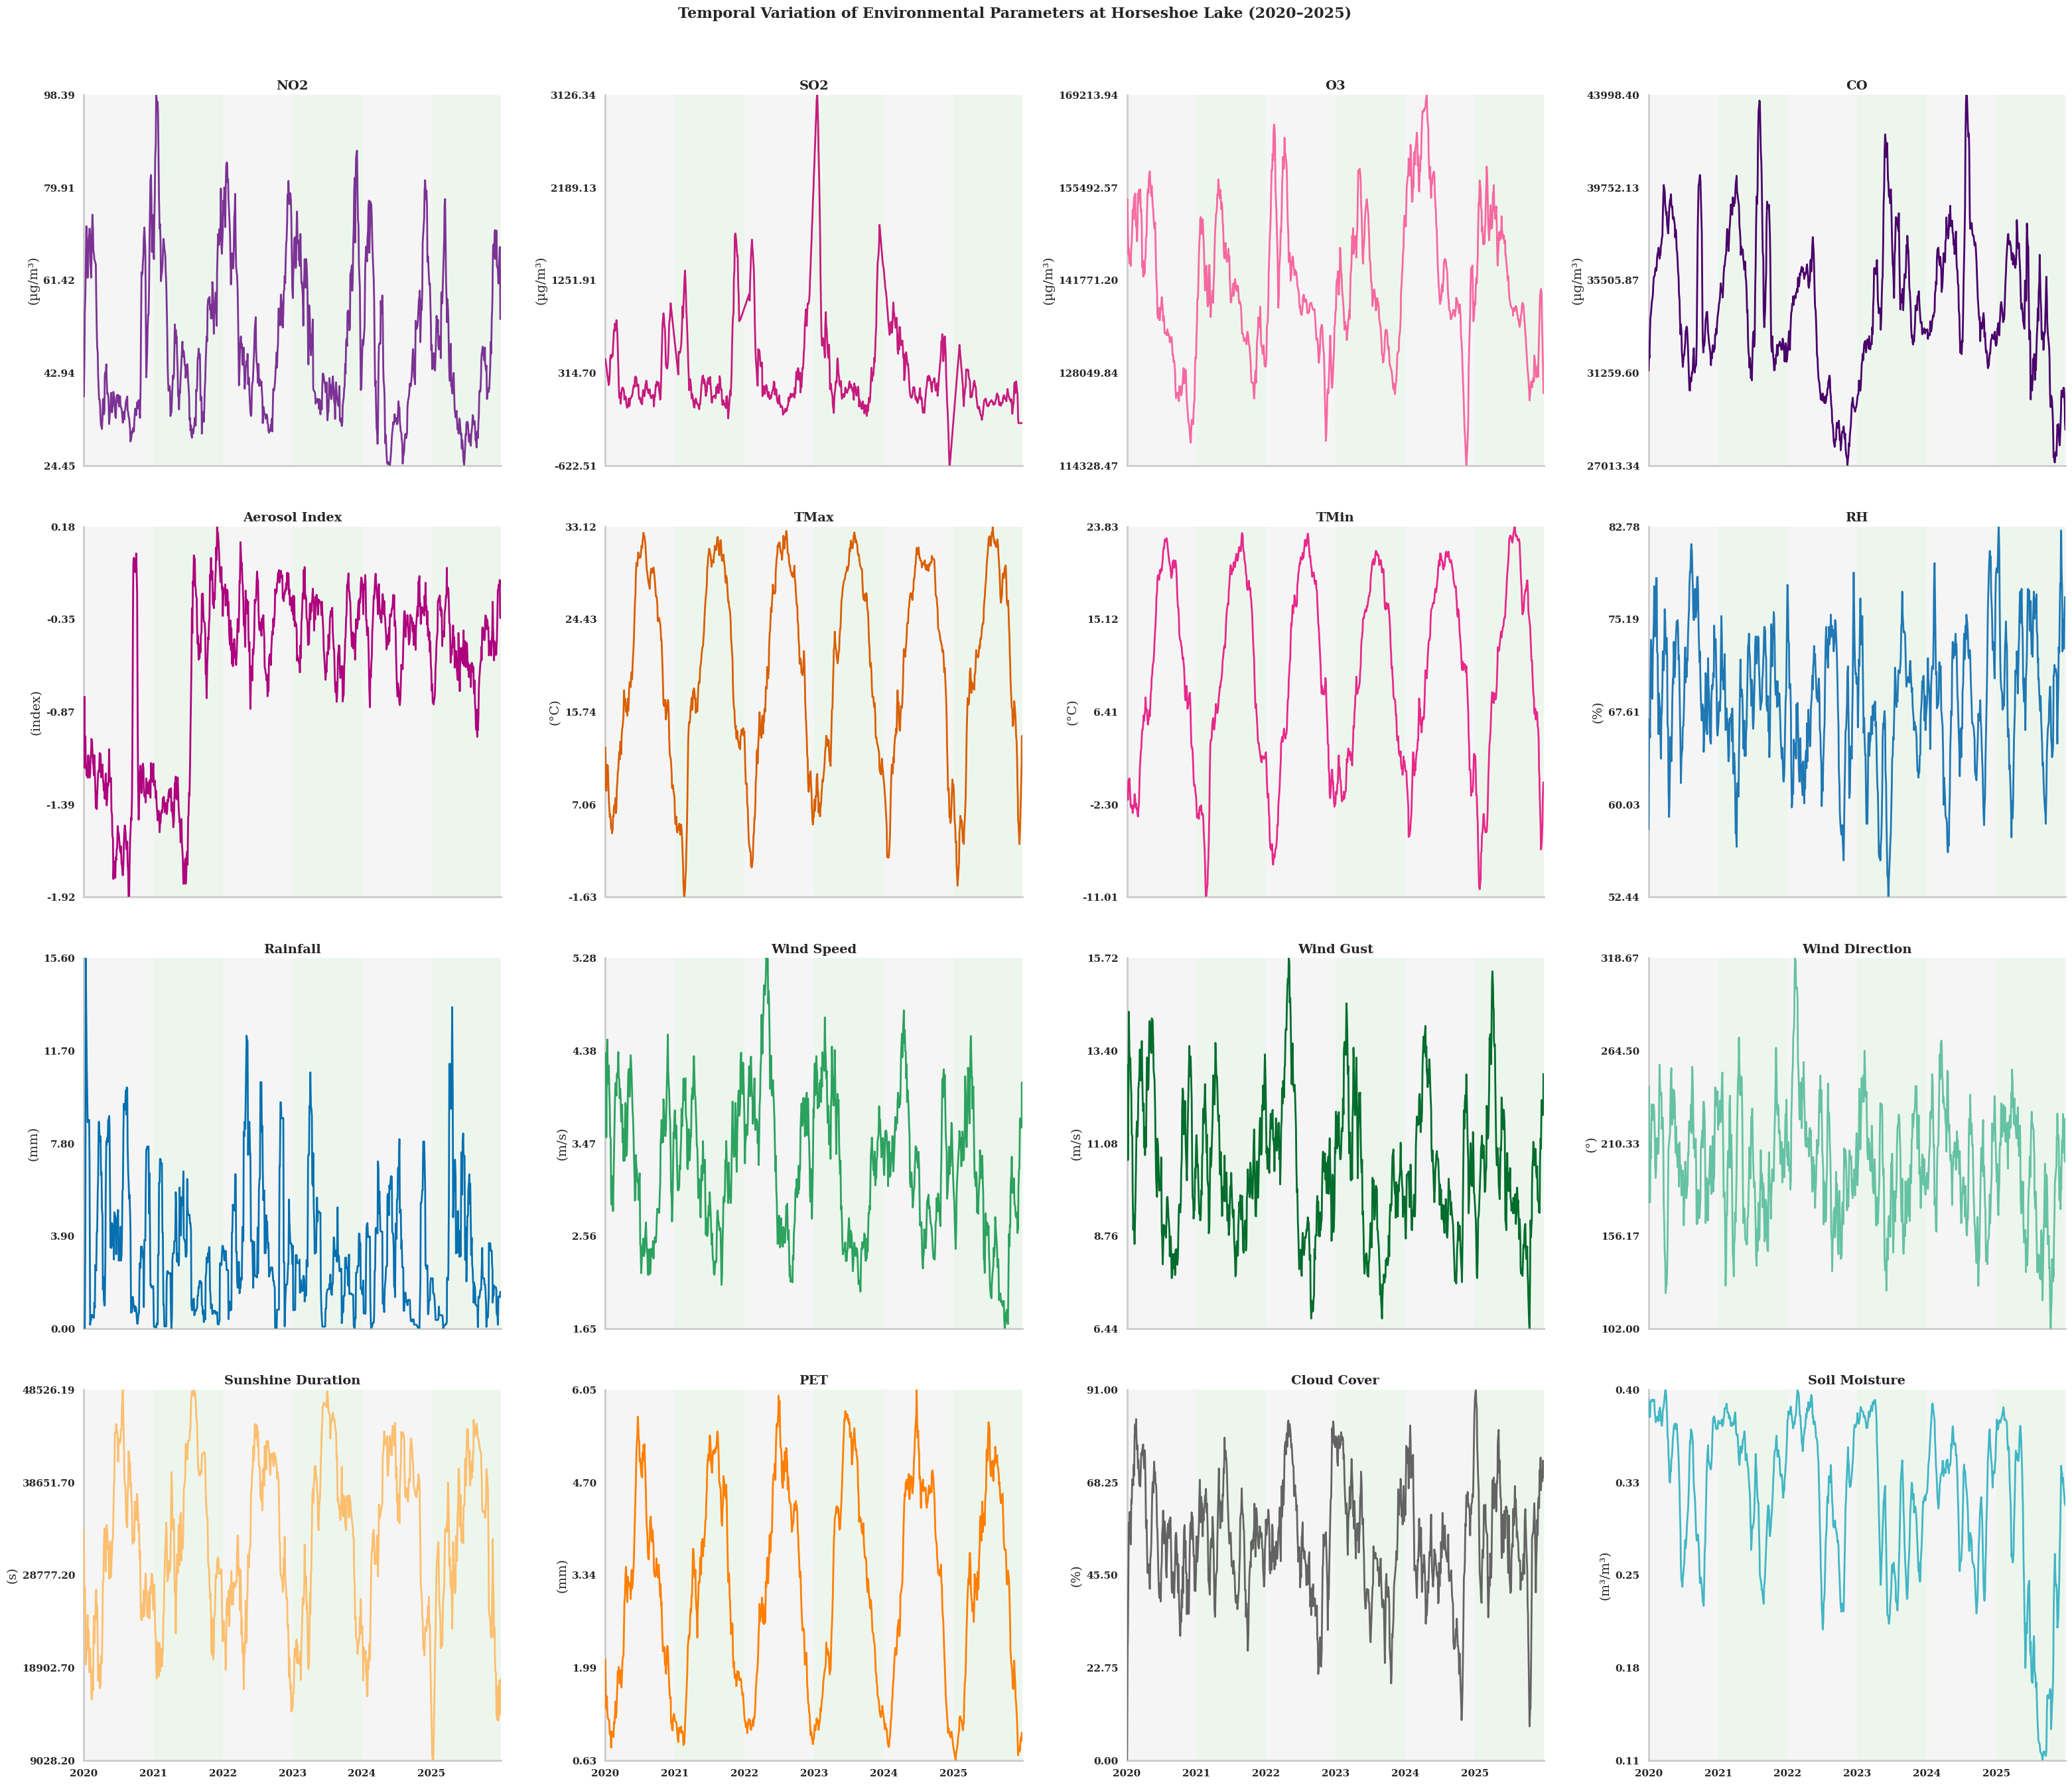

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

features = ['NO2','SO2','O3','CO','Aerosol_Index','TMax','TMin','RH',
            'Rainfall','Wind_Speed','Wind_Gust','Wind_Direction',
            'Sunshine_Duration','PET','Cloud_Cover','Soil_Moisture']

colors = {
    'NO2': '#7B3294', 'SO2': '#C51B7D', 'O3': '#F768A1', 'CO': '#49006A',
    'Aerosol_Index': '#AE017E', 'TMax': '#D95F02', 'TMin': '#E7298A', 'RH': '#1F78B4',
    'Rainfall': '#0570B0', 'Wind_Speed': '#2CA25F', 'Wind_Gust': '#006D2C', 'Wind_Direction': '#66C2A4',
    'Sunshine_Duration': '#FDBF6F', 'PET': '#FF7F00', 'Cloud_Cover': '#636363', 'Soil_Moisture': '#41B6C4'
}
units = {
    'NO2':'µg/m³','SO2':'µg/m³','O3':'µg/m³','CO':'µg/m³','Aerosol_Index':'index',
    'TMax':'°C','TMin':'°C','RH':'%','Rainfall':'mm','Wind_Speed':'m/s','Wind_Gust':'m/s',
    'Wind_Direction':'°','Sunshine_Duration':'s','PET':'mm','Cloud_Cover':'%','Soil_Moisture':'m³/m³'
}

yr0, yr1 = hsl['Date'].dt.year.min(), hsl['Date'].dt.year.max()
fig, axes = plt.subplots(4, 4, figsize=(32, 28))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    rolling = hsl[feature].rolling(window=9, min_periods=1).mean()

    for yr in range(yr0, yr1 + 1):
        ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'),
                   color='#F5F5F5' if yr % 2 == 0 else '#EDF6ED', zorder=0)

    ax.plot(hsl['Date'], rolling, color=colors[feature], linewidth=2.0, zorder=3)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(hsl['Date'].min(), hsl['Date'].max())

    ax.set_ylabel(f"({units[feature]})", fontsize=14)
    ax.set_title(feature.replace('_', ' '), fontsize=14, fontweight='bold')

    # 5 evenly spaced ticks across the data range (his style)
    dmin, dmax = rolling.min(), rolling.max()
    ax.set_ylim(dmin, dmax)
    ax.set_yticks(np.linspace(dmin, dmax, 5))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax.tick_params(axis='both', labelsize=11, width=1.5)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_linewidth(2)
    ax.grid(False)
    ax.set_facecolor('white')

for ax in axes[:-4]:
    ax.tick_params(axis='x', labelbottom=False)

fig.patch.set_facecolor('white')
plt.suptitle('Temporal Variation of Environmental Parameters at Horseshoe Lake (2020–2025)',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.02, 0.02, 1, 0.96], h_pad=4.0, w_pad=2.0)
plt.savefig('16_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pymannkendall as mk

mk_results = {}

for feature in features:
  series = hsl[feature].dropna()
  result = mk.yue_wang_modification_test(series, .10)
  mk_results[feature] = result

  print(f"--- {feature} ---")
  print(f"Trend: {result.trend}")
  print(f"p-value: {result.p:.4f}")
  print(f"Tau: {result.Tau:.4f}")
  print(f"Sen's slope: {result.slope:.6f}")
  print(f"Significant (p<0.05): {result.h}")
  print()

--- NO2 ---
Trend: decreasing
p-value: 0.0053
Tau: -0.0505
Sen's slope: -0.005440
Significant (p<0.05): True

--- SO2 ---
Trend: decreasing
p-value: 0.0119
Tau: -0.1029
Sen's slope: -0.264236
Significant (p<0.05): True

--- O3 ---
Trend: no trend
p-value: 0.8516
Tau: 0.0055
Sen's slope: 0.436830
Significant (p<0.05): False

--- CO ---
Trend: decreasing
p-value: 0.0049
Tau: -0.1023
Sen's slope: -2.589772
Significant (p<0.05): True

--- Aerosol_Index ---
Trend: increasing
p-value: 0.0000
Tau: 0.2351
Sen's slope: 0.001060
Significant (p<0.05): True

--- TMax ---
Trend: increasing
p-value: 0.0287
Tau: 0.0493
Sen's slope: 0.003026
Significant (p<0.05): True

--- TMin ---
Trend: increasing
p-value: 0.0286
Tau: 0.0499
Sen's slope: 0.002920
Significant (p<0.05): True

--- RH ---
Trend: no trend
p-value: 0.9913
Tau: 0.0002
Sen's slope: 0.000000
Significant (p<0.05): False

--- Rainfall ---
Trend: decreasing
p-value: 0.0975
Tau: -0.0265
Sen's slope: 0.000000
Significant (p<0.05): True

--- Wind_

In [ ]:
summary = []

for feature in features:
  r = mk_results[feature]
  summary.append({
      'Feature': feature,
      'Trend': r.trend,
      'p_value': r.p,
      'Tau': r.Tau,
      'Sen_slope': r.slope,
      'Significant': r.h
  })

mk_sum = pd.DataFrame(summary).sort_values('Tau').reset_index(drop=True)
mk_sum

,Feature,Trend,p_value,Tau,Sen_slope,Significant
0,Soil_Moisture,decreasing,2.476751e-08,-0.222330,-0.000089,True
1,SO2,decreasing,1.186661e-02,-0.102921,-0.264236,True
2,CO,decreasing,4.948690e-03,-0.102339,-2.589772,True
3,Wind_Speed,decreasing,3.303313e-05,-0.076909,-0.000556,True
4,NO2,decreasing,5.288618e-03,-0.050542,-0.005440,True
5,Wind_Direction,decreasing,2.274982e-07,-0.042333,-0.022599,True
6,Wind_Gust,decreasing,7.630864e-04,-0.037387,-0.000762,True
7,Rainfall,decreasing,9.753688e-02,-0.026526,0.000000,True
8,Cloud_Cover,decreasing,5.392265e-02,-0.021120,-0.003130,True
9,RH,no trend,9.913491e-01,0.000237,0.000000,False


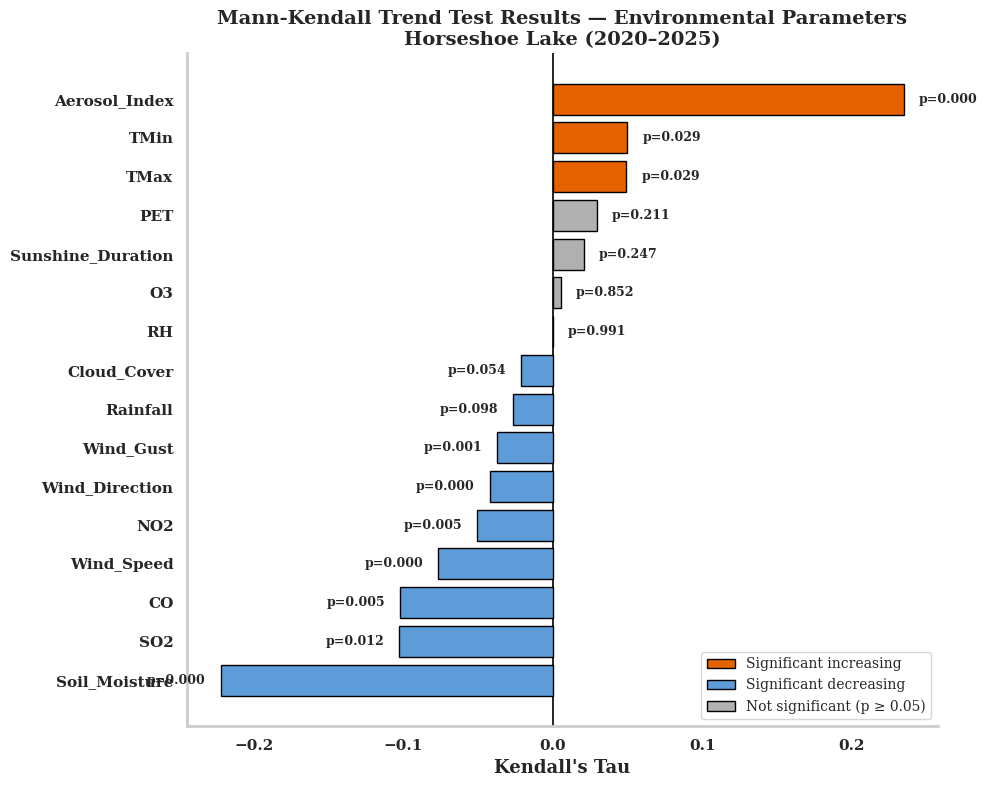

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10, 8))

bar_colors = []
for _, row in mk_sum.iterrows():
    if not row['Significant']:
        bar_colors.append('#B0B0B0')
    elif row['Trend'] == 'increasing':
        bar_colors.append('#E66100')
    else:
        bar_colors.append('#5D9BD9')

bars = ax.barh(mk_sum['Feature'], mk_sum['Tau'], color=bar_colors, edgecolor='black', linewidth=1.0, zorder=3)

for bar, p in zip(bars, mk_sum['p_value']):
    width = bar.get_width()
    label_x = width + 0.01 if width >= 0 else width - 0.01
    ha = 'left' if width >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f'p={p:.3f}',
            va='center', ha=ha, fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=1.2, zorder=2)
ax.set_xlabel("Kendall's Tau", fontsize=13, fontweight='bold')
ax.set_title('Mann-Kendall Trend Test Results — Environmental Parameters\nHorseshoe Lake (2020–2025)',
              fontsize=14, fontweight='bold')

ax.tick_params(axis='both', labelsize=11, width=1.5)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_linewidth(2)
ax.grid(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

legend_elements = [
    mpatches.Patch(facecolor='#E66100', edgecolor='black', label='Significant increasing'),
    mpatches.Patch(facecolor='#5D9BD9', edgecolor='black', label='Significant decreasing'),
    mpatches.Patch(facecolor='#B0B0B0', edgecolor='black', label='Not significant (p ≥ 0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('mk_trend_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pymannkendall as mk

test_subset = hsl[hsl['Date'] >= '2024-01-01']

mk_test_results = {}
for feature in features:
    series = test_subset[feature].dropna()
    result = mk.yue_wang_modification_test(series, .10)
    mk_test_results[feature] = result
    print(f"--- {feature} (test period only) ---")
    print(f"Trend: {result.trend}, p-value: {result.p:.4f}, n={len(series)}")
    print()

--- NO2 (test period only) ---
Trend: no trend, p-value: 0.6034, n=292

--- SO2 (test period only) ---
Trend: decreasing, p-value: 0.0000, n=292

--- O3 (test period only) ---
Trend: decreasing, p-value: 0.0000, n=292

--- CO (test period only) ---
Trend: decreasing, p-value: 0.0000, n=292

--- Aerosol_Index (test period only) ---
Trend: decreasing, p-value: 0.0001, n=292

--- TMax (test period only) ---
Trend: no trend, p-value: 0.4531, n=292

--- TMin (test period only) ---
Trend: no trend, p-value: 0.3659, n=292

--- RH (test period only) ---
Trend: increasing, p-value: 0.0094, n=292

--- Rainfall (test period only) ---
Trend: no trend, p-value: 0.8779, n=292

--- Wind_Speed (test period only) ---
Trend: decreasing, p-value: 0.0000, n=292

--- Wind_Gust (test period only) ---
Trend: decreasing, p-value: 0.0166, n=292

--- Wind_Direction (test period only) ---
Trend: decreasing, p-value: 0.0000, n=292

--- Sunshine_Duration (test period only) ---
Trend: no trend, p-value: 0.1262, n=2

In [ ]:
test_summary = []

for feature in features:
    r = mk_test_results[feature]
    test_summary.append({
        'Feature': feature,
        'Trend': r.trend,
        'p_value': r.p,
        'Tau': r.Tau,
        'Sen_slope': r.slope,
        'Significant': r.h
    })

mk_test_sum = pd.DataFrame(test_summary).sort_values('Tau').reset_index(drop=True)
mk_test_sum

,Feature,Trend,p_value,Tau,Sen_slope,Significant
0,O3,decreasing,2.439093e-11,-0.362143,-89.482355,True
1,CO,decreasing,3.330669e-15,-0.304053,-22.290586,True
2,Soil_Moisture,decreasing,7.278379e-07,-0.295792,-0.000472,True
3,SO2,decreasing,1.866516e-10,-0.262228,-1.741591,True
4,Wind_Speed,decreasing,1.591201e-09,-0.172151,-0.003606,True
5,Wind_Direction,decreasing,4.579565e-07,-0.083698,-0.135505,True
6,Sunshine_Duration,no trend,1.262137e-01,-0.063503,-13.142857,False
7,Wind_Gust,decreasing,1.661575e-02,-0.059879,-0.003593,True
8,Aerosol_Index,decreasing,1.440866e-04,-0.059243,-0.000568,True
9,PET,no trend,4.410091e-01,-0.049310,-0.001524,False
